<a href="https://colab.research.google.com/github/AlejaF/NLP_tarea3/blob/main/emoevent_bertweet_emociones3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Emociones en tuits con BERTweet: ¿congelar, ajustar o regularizar?

Un tuit sobre un incendio, un partido o unas elecciones puede expresar tristeza, enojo o alegría en muy pocas palabras, y a veces el único indicio es un emoji. Detectar esa emoción sirve para entender cómo reacciona la gente ante un suceso, pero no es sencillo: los textos son cortos y ruidosos, hay ironía, y la clase `others` (sin emoción marcada) domina sobre las demás.

En este trabajo se usa **BERTweet** (un RoBERTa preentrenado con cientos de millones de tuits en inglés) sobre **EmoEvent**, un corpus de tuits sobre ocho eventos de 2019 anotados con las seis emociones de Ekman más una categoría `others`.

### Pregunta de investigación
¿Cómo afecta la estrategia de adaptación de un Transformer preentrenado, desde mantener congelado el backbone hasta hacer fine-tuning completo con regularización, al desempeño y la generalización en la clasificación de emociones en tuits?

### Hipótesis de partida
1. Una cabeza más compleja sobre un backbone congelado mejorará poco, porque el límite lo pone la representación y no el clasificador.
2. El fine-tuning completo debería mejorar de forma clara, pero con unos pocos miles de tuits es probable que sobreajuste rápido.
3. La regularización reducirá la brecha entre entrenamiento y prueba; su efecto sobre el F1 final puede ser modesto.

### Estrategias que se comparan

| Modelo | BERTweet | Classification head | Objetivo |
|---|---|---|---|
| **M0 - Baseline** | congelado | Linear | Referencia |
| **M1 - MLP** | congelado | Linear → ReLU → Dropout → Linear | Evaluar una head más compleja |
| **M2 - Fine-tuning** | descongelado | Linear | Evaluar adaptación completa |
| **M3 - Fine-tuning + regularización** | descongelado | Linear + regularización | Estudiar overfitting y generalización |

### Cómo se hace la comparación
- La métrica principal es el **F1 macro**, no el accuracy, porque las clases están desbalanceadas y un modelo que solo acierte `others` tendría un accuracy engañoso.
- La época de cada modelo se elige con el conjunto de validación. El conjunto de prueba solo se usa al final.
- Cada modelo se entrena con **tres semillas** y se reporta media y desviación, ya que las diferencias entre estrategias pueden ser pequeñas.
- Además de M0 a M3 se incluyen: la normalización de tuits (URLs, menciones y emojis), pooling CLS frente a promedio, una búsqueda de tamaño y dropout para la MLP, un ablation de cada componente de regularización, un análisis de errores por clase y por evento, una proyección PCA de los embeddings y una demo con frases nuevas.

### Referencias
- Dataset: [SINAI/EmoEvent](https://huggingface.co/datasets/SINAI/EmoEvent). Plaza-del-Arco et al. (2020), *EmoEvent: A Multilingual Emotion Corpus based on different Events*, LREC.
- Modelo: [BERTweet](https://huggingface.co/vinai/bertweet-base). Nguyen, Vu y Nguyen (2020), *BERTweet: A pre-trained language model for English Tweets*, EMNLP (demos).
- Devlin et al. (2019), [BERT](http://arxiv.org/abs/1810.04805).
- Howard y Ruder (2018), *Universal Language Model Fine-tuning for Text Classification* (tasas de aprendizaje por capa).
- Notebook guía: `text-classification-with-hf.ipynb`.

In [1]:
%pip install -q emoji

import re
import time
import random
import warnings
from dataclasses import asdict, dataclass, replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from huggingface_hub import hf_hub_download
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 41.5 MB/s eta 0:00:00


## 1. Configuración

Se fijaron las semillas y se comprobó que Colab esté usando la GPU. El entrenamiento usa precisión mixta (fp16) para acelerar el fine-tuning.

In [2]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

MODEL_CKPT = "vinai/bertweet-base"
REPO_ID = "SINAI/EmoEvent"
SEEDS = [42, 7, 123]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = DEVICE == "cuda"
print(f"Dispositivo: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if USE_AMP else " -> activar la GPU en Entorno de ejecución"))


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEEDS[0])

Dispositivo: cuda (Tesla T4)


## 2. Datos

El repositorio de EmoEvent trae los splits oficiales (`splits/en/train.tsv`, `dev.tsv` y `test.tsv`), que se usan tal cual para poder comparar con otros trabajos. El separador es tabulador y hay comillas sueltas dentro de los tuits, por eso se desactiva el manejo de comillas al leer.

In [3]:
def load_split(name):
    path = hf_hub_download(REPO_ID, f"splits/en/{name}.tsv", repo_type="dataset")
    return pd.read_csv(path, sep="\t", quoting=3, dtype=str, keep_default_na=False)


raw = {"train": load_split("train"), "val": load_split("dev"), "test": load_split("test")}
for name, df in raw.items():
    print(f"{name:>5}: {len(df):>5} tuits")
data = raw["train"]   # el EDA se hace sobre el conjunto de entrenamiento
data.head()

train.tsv:   0%|          | 0.00/1.13M [00:00<?, ?B/s]

dev.tsv:   0%|          | 0.00/165k [00:00<?, ?B/s]

test.tsv:   0%|          | 0.00/319k [00:00<?, ?B/s]

train:  5112 tuits
  val:   744 tuits
 test:  1447 tuits


,id,event,tweet,offensive,emotion
0,3B9XR6P1WE1U78OX08FW8NXJL93BJG,NotreDame,I know that the Notre Dame is a very important...,NO,others
1,3P4ZBJFX2V96Q90CC9K7G3IC235WFF,Venezuela,#BREAKING: (USER) -- Trump threatens `full an...,NO,others
2,3IQ9O0AYW65Y8JY8ICLHWGO5E1JIT6,LaLiga,#Barcelona will win La Liga with three games t...,NO,others
3,3XEIP58NL0TWKWFD977CAKHEG1ZLZ3,LaLiga,HT: Decent half. A goal would've been good tho...,NO,others
4,3BFNCI9LYKWWKIJIK6BTNEUY6MU37E,GretaThunberg,In the 20th century we had weeping statues of ...,NO,others


## 3. Análisis exploratorio

### 3.1 Distribución de emociones
Se comparan las proporciones de cada clase en los tres splits. Si la partición está bien hecha, deberían parecerse.

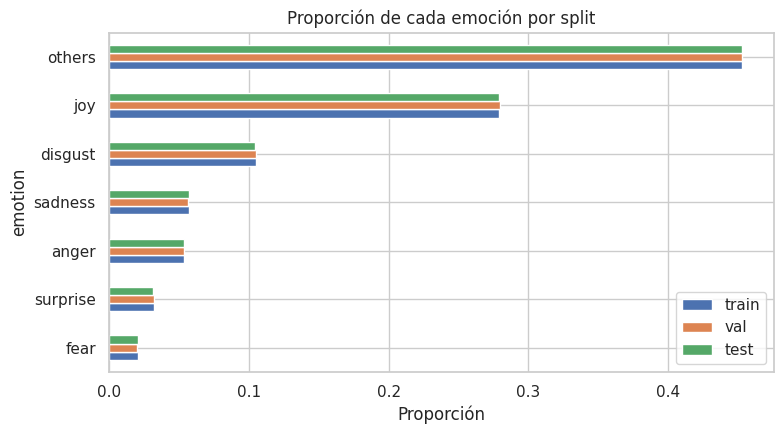

emotion
others      2313
joy         1427
disgust      536
sadness      291
anger        274
surprise     165
fear         106


In [4]:
LABELS = sorted(data["emotion"].unique())
assert len(LABELS) == 7, f"Etiquetas inesperadas: {LABELS}"
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
N_CLASSES = len(LABELS)

dist = pd.concat({s: d["emotion"].value_counts(normalize=True) for s, d in raw.items()}, axis=1).loc[LABELS]
ax = dist.sort_values("train").plot.barh(figsize=(8, 4.5))
ax.set_title("Proporción de cada emoción por split")
ax.set_xlabel("Proporción")
plt.tight_layout()
plt.show()
print(data["emotion"].value_counts().to_string())

### 3.2 Eventos y emociones
Cada tuit pertenece a un evento. Vale la pena ver si la emoción depende del evento, porque el modelo podría aprender "de qué se habla" en lugar de "qué se siente".

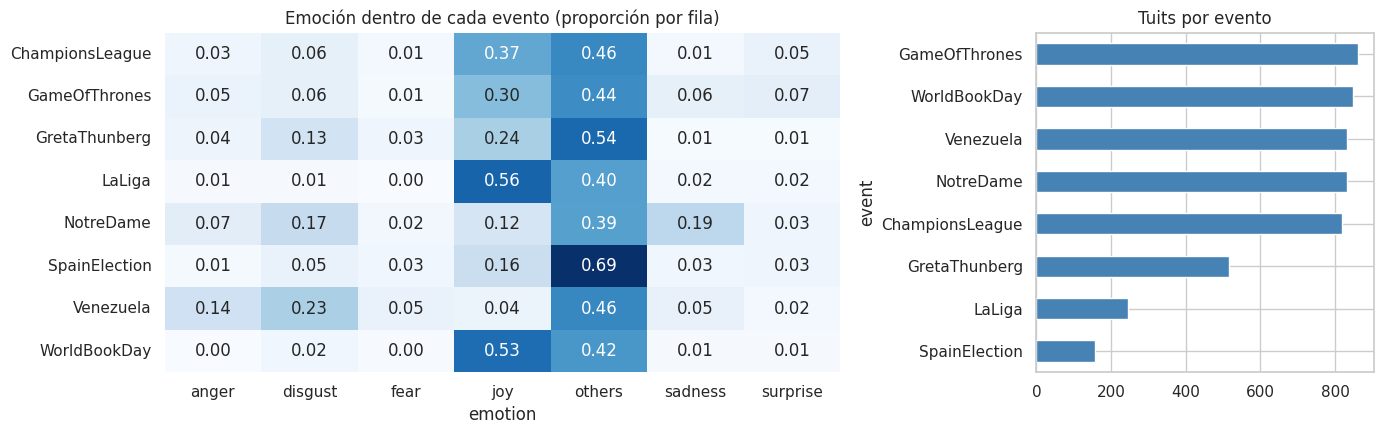

In [5]:
ct = pd.crosstab(data["event"], data["emotion"], normalize="index")[LABELS]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [2, 1]})
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Emoción dentro de cada evento (proporción por fila)")
axes[0].set_ylabel("")
data["event"].value_counts().sort_values().plot.barh(ax=axes[1], color="steelblue")
axes[1].set_title("Tuits por evento")
plt.tight_layout()
plt.show()

### 3.3 Longitud, lenguaje ofensivo y emojis
Se revisa cuánto escriben los usuarios según la emoción, qué proporción de tuits está marcada como ofensiva y cuánto peso tienen los emojis. Esto último decide si vale la pena tratarlos en el preprocesamiento.

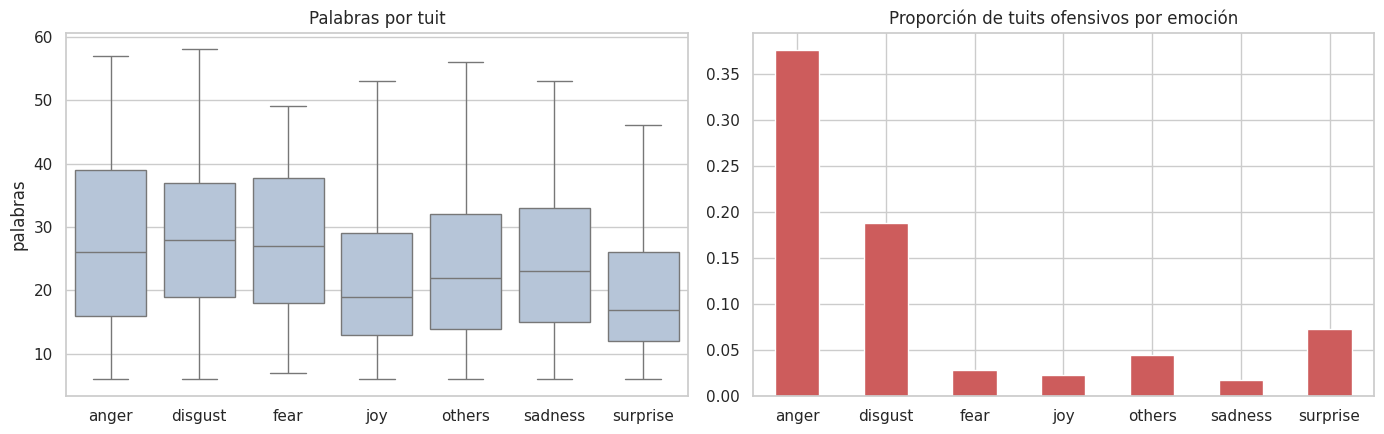

Tuits con al menos un emoji: 19.2%


,emojis más frecuentes
emotion,
anger,👏🏻 😤 🗣 👏 😡 ⛽
disgust,🤣 🤔 👏🏻 🆓 📘 😴
fear,👀 😂 😱 🌍 🔥 🇺🇸
joy,🏆 😂 📚 🔥 ❤️ ⚽
others,😂 📚 🏆 ⚽ 👇 🤔
sadness,😭 🇻🇪 😢 ❤️ 😔 💔
surprise,👏 ⚽ 🤯 😵 😮 🐐


In [6]:
train_eda = data.copy()
train_eda["palabras"] = train_eda["tweet"].str.split().str.len()
train_eda["ofensivo"] = train_eda["offensive"].str.upper().ne("NO")
train_eda["emojis"] = train_eda["tweet"].apply(lambda t: [e["emoji"] for e in emoji.emoji_list(t)])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=train_eda, x="emotion", y="palabras", order=LABELS, showfliers=False, color="lightsteelblue", ax=axes[0])
axes[0].set_title("Palabras por tuit")
axes[0].set_xlabel("")
train_eda.groupby("emotion")["ofensivo"].mean().reindex(LABELS).plot.bar(ax=axes[1], color="indianred")
axes[1].set_title("Proporción de tuits ofensivos por emoción")
axes[1].set_xlabel("")
plt.setp(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print(f"Tuits con al menos un emoji: {(train_eda['emojis'].str.len() > 0).mean():.1%}")
top_emojis = (train_eda.explode("emojis").dropna(subset=["emojis"]).groupby("emotion")["emojis"]
              .agg(lambda s: " ".join(s.value_counts().head(6).index)).reindex(LABELS))
top_emojis.to_frame("emojis más frecuentes")

### 3.4 Duplicados y posibles fugas
En Twitter abundan los retuits y las copias casi idénticas. Si un mismo texto está en train y en test, el resultado de prueba queda inflado. Esto se verifica una vez limpiados los textos (sección 4).

## 4. Preprocesamiento

BERTweet se entrenó con tuits normalizados, así que los textos se le entregan en ese mismo formato:

- **URLs y menciones** se reemplazan por los marcadores `HTTPURL` y `@USER`, porque la dirección o el nombre de usuario no aportan emoción.
- **Emojis**: suelen ser la señal emocional más fuerte del tuit. La normalización los convierte en su nombre en texto (😭 → `:loudly_crying_face:`), que el modelo sí conoce.
- **Hashtags**: se conservan tal cual, porque muchas veces dicen de qué se habla.

El texto no se pasa a minúsculas porque BERTweet distingue mayúsculas de minúsculas. Se usa el normalizador del propio tokenizador para no diferir de lo que vio el modelo en el preentrenamiento.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)
clean_tweet = AutoTokenizer.from_pretrained(MODEL_CKPT, normalization=True).normalizeTweet

for t in data.sample(4, random_state=1)["tweet"]:
    print("ORIGINAL:", t)
    print("LIMPIO  :", clean_tweet(t), "\n")


def unk_rate(texts):
    ids = tokenizer(list(texts), add_special_tokens=False)["input_ids"]
    return np.mean([tokenizer.unk_token_id in x for x in ids])


tr = data["tweet"]
print(f"Tuits con algún <unk> antes de limpiar : {unk_rate(tr):.1%}")
print(f"Tuits con algún <unk> después de limpiar: {unk_rate(tr.map(clean_tweet)):.1%}")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

ORIGINAL: Not massively hopeful after last night’s results. If USER get into bed with USER to govern, get ready to have your wallets raided. #SpainElection
LIMPIO  : Not massively hopeful after last night 's results . If USER get into bed with USER to govern , get ready to have your wallets raided . #SpainElection 

ORIGINAL: USER #WorldBookDay  Me with my recent read. Awesome book.. loved the way USER narrate the story. Some of my believes got shaken, Got explanation of some of the questions in my mind. Truly one of my favorite book. USER_great  USER  USER_Amruta06 https://t.co/ZzV0OgbKev
LIMPIO  : USER #WorldBookDay Me with my recent read . Awesome book .. loved the way USER narrate the story . Some of my believes got shaken , Got explanation of some of the questions in my mind . Truly one of my favorite book . USER_great USER USER_Amruta 06 HTTPURL 

ORIGINAL: "🤢#TheFive You know, it's tough enough watching all of you ""party"" in Nashville, after we just watched the #NotreDameCathe

Se aplica la limpieza a todos los splits, se eliminan los duplicados dentro de train y se quitan de validación y prueba los tuits cuyo texto ya aparece en train.

In [8]:
splits = {}
for name, df in raw.items():
    df = df[["tweet", "event", "emotion"]].copy()
    df["clean"] = df["tweet"].map(clean_tweet)
    df["label"] = df["emotion"].map(LABEL2ID)
    splits[name] = df

n_dup = splits["train"]["clean"].duplicated().sum()
splits["train"] = splits["train"].drop_duplicates("clean").reset_index(drop=True)
seen = set(splits["train"]["clean"])
print(f"Duplicados eliminados en train: {n_dup}")
for name in ("val", "test"):
    leak = splits[name]["clean"].isin(seen)
    print(f"Filas de {name} que ya estaban en train: {leak.sum()}")
    splits[name] = splits[name][~leak].reset_index(drop=True)

print({k: len(v) for k, v in splits.items()})

Duplicados eliminados en train: 19
Filas de val que ya estaban en train: 8
Filas de test que ya estaban en train: 5
{'train': 5093, 'val': 736, 'test': 1442}


### Longitud de secuencia
`MAX_LEN` se elige según los datos: el percentil 99 de la longitud en tokens, redondeado a múltiplo de 8 y con tope en 128, que es lo máximo que admite BERTweet. Así casi ningún tuit se trunca y no se desperdicia cómputo.

Tokens por tuit -> mediana: 34 | p95: 64 | p99: 72 | máx: 150
MAX_LEN = 72  (tuits truncados: 0.92%)


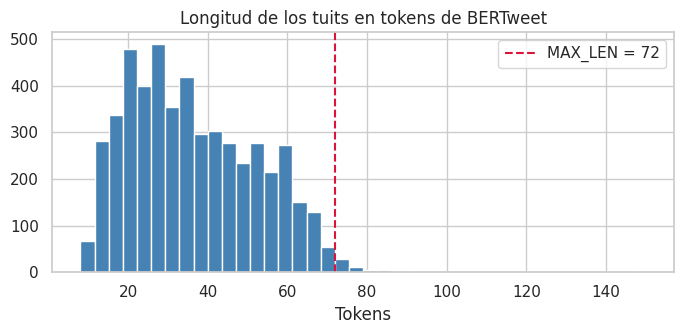

,anger,disgust,fear,joy,others,sadness,surprise
peso,2.67,1.37,6.86,0.51,0.32,2.52,4.41


In [9]:
lens = np.array([len(x) for x in tokenizer(splits["train"]["clean"].tolist())["input_ids"]])
MAX_LEN = min(128, int(np.ceil(np.percentile(lens, 99) / 8) * 8))
print(f"Tokens por tuit -> mediana: {np.median(lens):.0f} | p95: {np.percentile(lens, 95):.0f} | p99: {np.percentile(lens, 99):.0f} | máx: {lens.max()}")
print(f"MAX_LEN = {MAX_LEN}  (tuits truncados: {(lens > MAX_LEN).mean():.2%})")

plt.figure(figsize=(7, 3.5))
plt.hist(lens, bins=40, color="steelblue")
plt.axvline(MAX_LEN, color="crimson", ls="--", label=f"MAX_LEN = {MAX_LEN}")
plt.title("Longitud de los tuits en tokens de BERTweet")
plt.xlabel("Tokens")
plt.legend()
plt.tight_layout()
plt.show()

ENC = {s: tokenizer(d["clean"].tolist(), max_length=MAX_LEN, truncation=True, padding="max_length", return_tensors="pt")
       for s, d in splits.items()}
Y = {s: torch.tensor(d["label"].values) for s, d in splits.items()}

# Pesos por clase (inverso de la frecuencia) para compensar el desbalance en la pérdida
CLASS_W = torch.tensor(compute_class_weight("balanced", classes=np.arange(N_CLASSES), y=Y["train"].numpy()),
                       dtype=torch.float32, device=DEVICE)
pd.Series(CLASS_W.cpu().numpy(), index=LABELS, name="peso").round(2).to_frame().T

### Lo que muestra el EDA
- **Desbalance fuerte.** `others` reúne cerca del 45 % de los tuits y `joy` el 28 %, mientras que `fear` y `surprise` no llegan al 3 %. Por eso se usa F1 macro y una pérdida ponderada (el peso de `fear` es unas 20 veces el de `others`). Las proporciones son casi idénticas en train, validación y prueba, así que la comparación entre splits es justa.
- **La emoción depende del evento.** Notre Dame concentra tristeza y asco, Venezuela tiene el mayor enojo y asco, LaLiga y el Día del Libro son sobre todo alegría, y en las elecciones casi el 70 % es `others`. El evento es una pista fuerte, y el riesgo es que el modelo aprenda el tema en lugar de la emoción; esto se revisa más adelante con el rendimiento por evento.
- **Longitud y tono.** Los tuits de enojo, asco, miedo y tristeza son más largos (mediana de unas 26 a 28 palabras) que los de alegría o sorpresa (17 a 19). El lenguaje ofensivo se concentra en enojo (cerca del 37 %) y asco (19 %), y en el resto de clases es marginal.
- **Emojis y limpieza.** Solo el 19 % de los tuits trae emojis, menos de lo esperado, así que su normalización ayuda pero no es determinante. Se eliminaron 19 duplicados en train y 8 y 5 tuits de validación y prueba que ya estaban en train. Con `MAX_LEN = 72` solo se trunca el 0.9 % de los tuits.

## 5. Implementación de los modelos

Para tener control total sobre lo que se congela, las tasas de aprendizaje y la regularización, se escribió un ciclo de entrenamiento propio en PyTorch en lugar de usar `Trainer`. Todo el código se reutiliza en los cuatro modelos.

**Un detalle que ahorra tiempo.** Con el backbone congelado y en modo `eval`, la salida de BERTweet para un tuit es siempre la misma. Por eso M0 y M1 se entrenan sobre embeddings calculados una sola vez (representación del token `[CLS]` y promedio de tokens, que se usa más adelante), lo que reduce el entrenamiento de esos modelos a segundos y permite explorar muchas variantes de la head.

In [10]:
@dataclass(frozen=True)
class Cfg:
    name: str
    head: str = "linear"          # "linear" o "mlp"
    freeze_backbone: bool = True
    pooling: str = "cls"          # solo aplica con backbone congelado: "cls" o "mean"
    epochs: int = 40
    batch: int = 64
    lr: float = 2e-5              # backbone
    head_lr: float = 1e-3         # head
    wd: float = 0.0
    smoothing: float = 0.0
    head_dropout: float = 0.0
    bert_dropout: float = 0.1
    llrd: float = 1.0             # factor de decaimiento de lr por capa hacia abajo
    hidden: int = 256
    warmup: float = 0.1


def make_head(kind, dim, hidden, dropout):
    if kind == "linear":
        return nn.Sequential(nn.Dropout(dropout), nn.Linear(dim, N_CLASSES))
    return nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, N_CLASSES))


class TweetClassifier(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(
            MODEL_CKPT, add_pooling_layer=False,
            hidden_dropout_prob=cfg.bert_dropout, attention_probs_dropout_prob=cfg.bert_dropout)
        self.head = make_head(cfg.head, self.backbone.config.hidden_size, cfg.hidden, cfg.head_dropout)

    def forward(self, ids, mask):
        return self.head(self.backbone(input_ids=ids, attention_mask=mask).last_hidden_state[:, 0])


@torch.no_grad()
def encode(backbone, enc, batch_size=128):
    # Devuelve el embedding de [CLS] y el promedio de tokens (sin padding) de cada texto.
    backbone.eval()
    cls, mean = [], []
    for i in range(0, len(enc["input_ids"]), batch_size):
        ids = enc["input_ids"][i:i + batch_size].to(DEVICE)
        mask = enc["attention_mask"][i:i + batch_size].to(DEVICE)
        with torch.autocast(DEVICE, dtype=torch.float16, enabled=USE_AMP):
            h = backbone(input_ids=ids, attention_mask=mask).last_hidden_state.float()
        m = mask.unsqueeze(-1)
        cls.append(h[:, 0].cpu())
        mean.append(((h * m).sum(1) / m.sum(1)).cpu())
    return {"cls": torch.cat(cls), "mean": torch.cat(mean)}


def param_groups(model, cfg):
    # Agrupa parámetros por (lr, weight decay). Bias y LayerNorm no llevan weight decay.
    buckets = {}

    def add(name, p, lr):
        wd = 0.0 if ("bias" in name or "LayerNorm.weight" in name) else cfg.wd
        buckets.setdefault((lr, wd), []).append(p)

    if isinstance(model, TweetClassifier):
        n_layers = model.backbone.config.num_hidden_layers
        for n, p in model.head.named_parameters():
            add(n, p, cfg.head_lr)
        for n, p in model.backbone.named_parameters():
            m = re.match(r"encoder\.layer\.(\d+)\.", n)
            depth = int(m.group(1)) + 1 if m else 0   # embeddings = 0, última capa = n_layers
            add(n, p, cfg.lr * cfg.llrd ** (n_layers - depth))
    else:
        for n, p in model.named_parameters():
            add(n, p, cfg.head_lr)
    return [{"params": ps, "lr": lr, "weight_decay": wd} for (lr, wd), ps in buckets.items()]


def evaluate(model, loader):
    model.eval()
    logits, ys = [], []
    with torch.no_grad(), torch.autocast(DEVICE, dtype=torch.float16, enabled=USE_AMP):
        for *xs, y in loader:
            logits.append(model(*[x.to(DEVICE) for x in xs]).float().cpu())
            ys.append(y)
    logits, y = torch.cat(logits), torch.cat(ys)
    pred = logits.argmax(1).numpy()
    y = y.numpy()
    return {"loss": F.cross_entropy(logits, torch.tensor(y), weight=CLASS_W.cpu()).item(),
            "acc": accuracy_score(y, pred), "f1": f1_score(y, pred, average="macro"),
            "logits": logits.numpy(), "y": y, "pred": pred}


def fit(model, loaders, cfg):
    opt = torch.optim.AdamW(param_groups(model, cfg))
    total = cfg.epochs * len(loaders["train"])
    sched = get_linear_schedule_with_warmup(opt, int(cfg.warmup * total), total)
    scaler = torch.amp.GradScaler(DEVICE, enabled=USE_AMP)
    criterion = nn.CrossEntropyLoss(weight=CLASS_W, label_smoothing=cfg.smoothing)
    history, best_f1, best_state = [], -1.0, None

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        loss_sum, w_sum = torch.zeros((), device=DEVICE), torch.zeros((), device=DEVICE)
        for *xs, y in loaders["train"]:
            xs, y = [x.to(DEVICE) for x in xs], y.to(DEVICE)
            with torch.autocast(DEVICE, dtype=torch.float16, enabled=USE_AMP):
                logits = model(*xs)
            loss = criterion(logits.float(), y)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            sched.step()
            # Pérdida de train sin label smoothing, para poder compararla con la de validación
            loss_sum += F.cross_entropy(logits.detach().float(), y, weight=CLASS_W, reduction="sum")
            w_sum += CLASS_W[y].sum()
        val = evaluate(model, loaders["val"])
        history.append({"epoch": epoch, "train_loss": (loss_sum / w_sum).item(),
                        "val_loss": val["loss"], "val_f1": val["f1"], "val_acc": val["acc"]})
        if val["f1"] > best_f1:
            best_f1 = val["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    hist = pd.DataFrame(history)
    return hist, int(hist["val_f1"].idxmax()) + 1


def run_experiment(cfg, seed, keep_model=False):
    set_seed(seed)
    t0 = time.time()
    if cfg.freeze_backbone:
        X = {s: FEATS[s][cfg.pooling] for s in ENC}
        model = make_head(cfg.head, X["train"].shape[1], cfg.hidden, cfg.head_dropout).to(DEVICE)
        data = {s: TensorDataset(X[s], Y[s]) for s in ENC}
    else:
        model = TweetClassifier(cfg).to(DEVICE)
        data = {s: TensorDataset(ENC[s]["input_ids"], ENC[s]["attention_mask"], Y[s]) for s in ENC}

    gen = torch.Generator().manual_seed(seed)
    loaders = {"train": DataLoader(data["train"], batch_size=cfg.batch, shuffle=True, generator=gen)}
    loaders.update({s: DataLoader(data[s], batch_size=128) for s in ("val", "test")})
    hist, best_epoch = fit(model, loaders, cfg)

    ev = {s: evaluate(model, DataLoader(data[s], batch_size=128)) for s in ("train", "val", "test")}
    res = {"cfg": cfg, "seed": seed, "history": hist, "best_epoch": best_epoch,
           "train_f1": ev["train"]["f1"], "val_f1": ev["val"]["f1"],
           "test_f1": ev["test"]["f1"], "test_acc": ev["test"]["acc"],
           "test_pred": ev["test"]["pred"], "test_logits": ev["test"]["logits"],
           "trainable": sum(p.numel() for p in model.parameters() if p.requires_grad),
           "seconds": time.time() - t0}
    res["test_feats"] = (FEATS["test"]["cls"] if cfg.freeze_backbone
                         else encode(model.backbone, ENC["test"])["cls"]).numpy()
    if keep_model:
        res["model"] = model.cpu()
    else:
        del model
    if USE_AMP:
        torch.cuda.empty_cache()
    return res

### Extracción de embeddings congelados
Todos los tuits pasan una sola vez por BERTweet y se guardan los embeddings. Después se libera el modelo de la GPU.

In [11]:
frozen = AutoModel.from_pretrained(MODEL_CKPT, add_pooling_layer=False).to(DEVICE)
for p in frozen.parameters():
    p.requires_grad = False

t0 = time.time()
FEATS = {s: encode(frozen, ENC[s]) for s in ENC}
print(f"Embeddings listos en {time.time() - t0:.0f} s | dimensión: {FEATS['train']['cls'].shape[1]}")
n_backbone = sum(p.numel() for p in frozen.parameters())
print(f"Parámetros del backbone: {n_backbone / 1e6:.1f} M")
del frozen
if USE_AMP:
    torch.cuda.empty_cache()

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  543MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
lm_head.decoder.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.decoder.bias        | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

model.safetensors: downloading bytes:           |  0.00B            

Embeddings listos en 7 s | dimensión: 768
Parámetros del backbone: 134.3 M


### Definición de M0 a M3

- **M0**: una sola capa lineal sobre el `[CLS]` congelado.
- **M1**: `Linear(768→256) → ReLU → Dropout(0.3) → Linear(256→7)`, también sobre backbone congelado.
- **M2**: todo BERTweet entrenable con una capa lineal, `lr = 2e-5`, sin regularización adicional. Solo se aplica el recorte de gradiente y el *warmup*, que son estándar.
- **M3**: igual que M2 pero con cuatro mecanismos de regularización: *weight decay* de 0.05, *label smoothing* de 0.1, más dropout (0.3 en la head y 0.2 dentro de BERTweet) y *layer-wise learning rate decay* de 0.9, que entrena más despacio las capas inferiores, las más generales, para que no se "olviden" del preentrenamiento.

Los modelos congelados usan 40 épocas porque la head es pequeña y entrena en segundos; los que ajustan BERTweet, 8, porque con regularización el modelo converge más despacio. En todos se conserva la época con mejor F1 macro de validación.

In [12]:
CFGS = {
    "M0": Cfg("M0 Baseline", head="linear"),
    "M1": Cfg("M1 MLP", head="mlp", head_dropout=0.3),
    "M2": Cfg("M2 Fine-tuning", freeze_backbone=False, epochs=8, batch=32),
    "M3": Cfg("M3 Fine-tuning + reg.", freeze_backbone=False, epochs=8, batch=32,
              wd=0.05, smoothing=0.1, head_dropout=0.3, bert_dropout=0.2, llrd=0.9),
}
pd.DataFrame({k: asdict(c) for k, c in CFGS.items()}).drop(index="name")

,M0,M1,M2,M3
head,linear,mlp,linear,linear
freeze_backbone,True,True,False,False
pooling,cls,cls,cls,cls
epochs,40,40,8,8
batch,64,64,32,32
lr,0.00002,0.00002,0.00002,0.00002
head_lr,0.001,0.001,0.001,0.001
wd,0.0,0.0,0.0,0.05
smoothing,0.0,0.0,0.0,0.1
head_dropout,0.0,0.3,0.0,0.3


## 6. Experimento principal: M0 a M3 con tres semillas
Se guarda el modelo completo de la primera semilla en los dos modelos con fine-tuning, para usarlo después en la demo.

In [13]:
RESULTS = {}
for key, cfg in CFGS.items():
    for seed in SEEDS:
        keep = (not cfg.freeze_backbone) and seed == SEEDS[0]
        r = run_experiment(cfg, seed, keep_model=keep)
        RESULTS[(key, seed)] = r
        print(f"{cfg.name:<24} semilla {seed:>3} | época {r['best_epoch']:>2} | "
              f"train F1 {r['train_f1']:.3f} | val F1 {r['val_f1']:.3f} | test F1 {r['test_f1']:.3f} | {r['seconds']:.0f} s")

M0 Baseline              semilla  42 | época 29 | train F1 0.427 | val F1 0.361 | test F1 0.347 | 20 s
M0 Baseline              semilla   7 | época 32 | train F1 0.425 | val F1 0.348 | test F1 0.355 | 11 s
M0 Baseline              semilla 123 | época 36 | train F1 0.416 | val F1 0.347 | test F1 0.344 | 9 s
M1 MLP                   semilla  42 | época 29 | train F1 0.494 | val F1 0.384 | test F1 0.364 | 10 s
M1 MLP                   semilla   7 | época 16 | train F1 0.476 | val F1 0.384 | test F1 0.379 | 11 s
M1 MLP                   semilla 123 | época 35 | train F1 0.511 | val F1 0.380 | test F1 0.365 | 10 s


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
lm_head.decoder.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.decoder.bias        | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


M2 Fine-tuning           semilla  42 | época  8 | train F1 0.920 | val F1 0.506 | test F1 0.481 | 210 s


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
lm_head.decoder.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.decoder.bias        | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


M3 Fine-tuning + reg.    semilla   7 | época  6 | train F1 0.542 | val F1 0.453 | test F1 0.432 | 215 s


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
lm_head.decoder.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.decoder.bias        | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


M3 Fine-tuning + reg.    semilla 123 | época  7 | train F1 0.560 | val F1 0.447 | test F1 0.437 | 215 s


In [14]:
def mean_std(s):
    return f"{s.mean():.3f} ± {s.std():.3f}"


def summary_table(results):
    rows = [{"modelo": r["cfg"].name, "val F1": r["val_f1"], "test F1": r["test_f1"], "test acc": r["test_acc"],
             "train F1": r["train_f1"], "brecha (train-test)": r["train_f1"] - r["test_f1"],
             "mejor época": r["best_epoch"], "params entrenables": r["trainable"], "segundos": r["seconds"]}
            for r in results]
    df = pd.DataFrame(rows)
    g = df.groupby("modelo", sort=False)
    out = g[["val F1", "test F1", "test acc", "train F1", "brecha (train-test)"]].agg(mean_std)
    out["mejor época"] = g["mejor época"].agg(lambda s: f"{s.mean():.1f}")
    out["params entrenables"] = g["params entrenables"].first().map("{:,}".format)
    out["segundos"] = g["segundos"].mean().round(0).astype(int)
    return out


main_table = summary_table(RESULTS.values())
main_table

,val F1,test F1,test acc,train F1,brecha (train-test),mejor época,params entrenables,segundos
modelo,,,,,,,,
M0 Baseline,0.352 ± 0.008,0.349 ± 0.006,0.421 ± 0.009,0.423 ± 0.006,0.074 ± 0.006,32.3,"5,383",13
M1 MLP,0.383 ± 0.002,0.369 ± 0.008,0.458 ± 0.015,0.494 ± 0.018,0.124 ± 0.025,26.7,"198,663",10
M2 Fine-tuning,0.509 ± 0.005,0.489 ± 0.008,0.605 ± 0.004,0.882 ± 0.044,0.394 ± 0.051,6.7,"134,314,759",209
M3 Fine-tuning + reg.,0.446 ± 0.008,0.435 ± 0.003,0.496 ± 0.008,0.550 ± 0.009,0.115 ± 0.007,6.3,"134,314,759",214


La tabla muestra media ± desviación sobre tres semillas. La columna "brecha" es el F1 macro en entrenamiento menos el F1 en prueba, una medida directa de cuánto se sobreajusta cada estrategia. Ahora la misma comparación en gráficos, junto a las curvas de aprendizaje de la primera semilla.

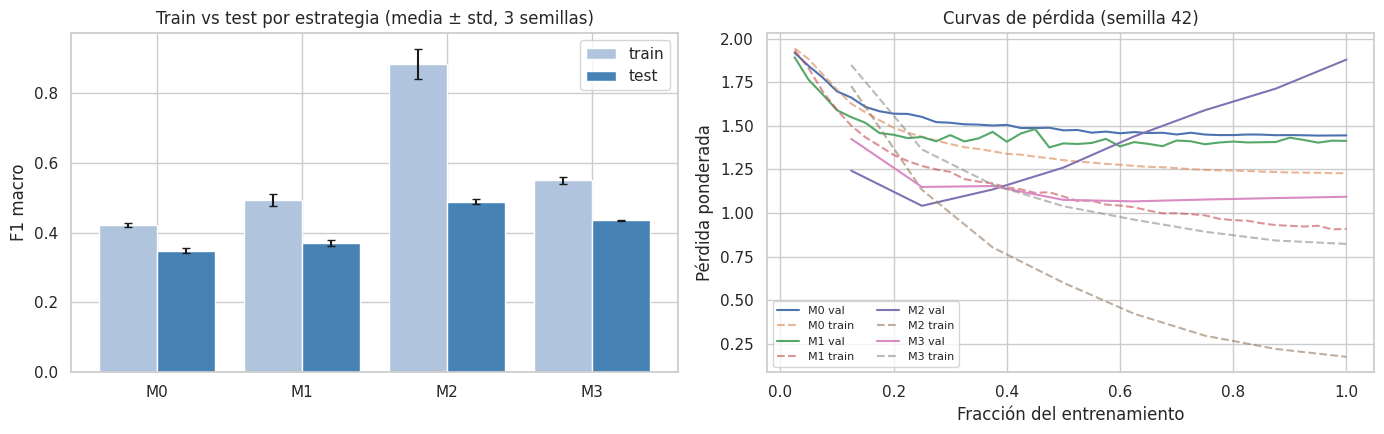

In [15]:
order = [c.name for c in CFGS.values()]
agg = pd.DataFrame([{"modelo": r["cfg"].name, "test F1": r["test_f1"], "train F1": r["train_f1"]} for r in RESULTS.values()])
agg = agg.groupby("modelo").agg(["mean", "std"]).loc[order]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(order))
axes[0].bar(x - 0.2, agg[("train F1", "mean")], 0.4, yerr=agg[("train F1", "std")], label="train", color="lightsteelblue", capsize=3)
axes[0].bar(x + 0.2, agg[("test F1", "mean")], 0.4, yerr=agg[("test F1", "std")], label="test", color="steelblue", capsize=3)
axes[0].set_xticks(x)
axes[0].set_xticklabels([o.split(" ")[0] for o in order])
axes[0].set_ylabel("F1 macro")
axes[0].set_title("Train vs test por estrategia (media ± std, 3 semillas)")
axes[0].legend()

for key, cfg in CFGS.items():
    h = RESULTS[(key, SEEDS[0])]["history"]
    # eje x en fracción del entrenamiento para poder comparar 40 vs 5 épocas
    axes[1].plot(h["epoch"] / cfg.epochs, h["val_loss"], label=f"{key} val")
    axes[1].plot(h["epoch"] / cfg.epochs, h["train_loss"], ls="--", alpha=0.6, label=f"{key} train")
axes[1].set_xlabel("Fracción del entrenamiento")
axes[1].set_ylabel("Pérdida ponderada")
axes[1].set_title(f"Curvas de pérdida (semilla {SEEDS[0]})")
axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

### Curvas de los modelos con fine-tuning
Aquí se ve mejor el sobreajuste: la pérdida de train sigue bajando, y lo que importa es en qué época la de validación deja de mejorar y cómo se comporta M3 frente a M2.

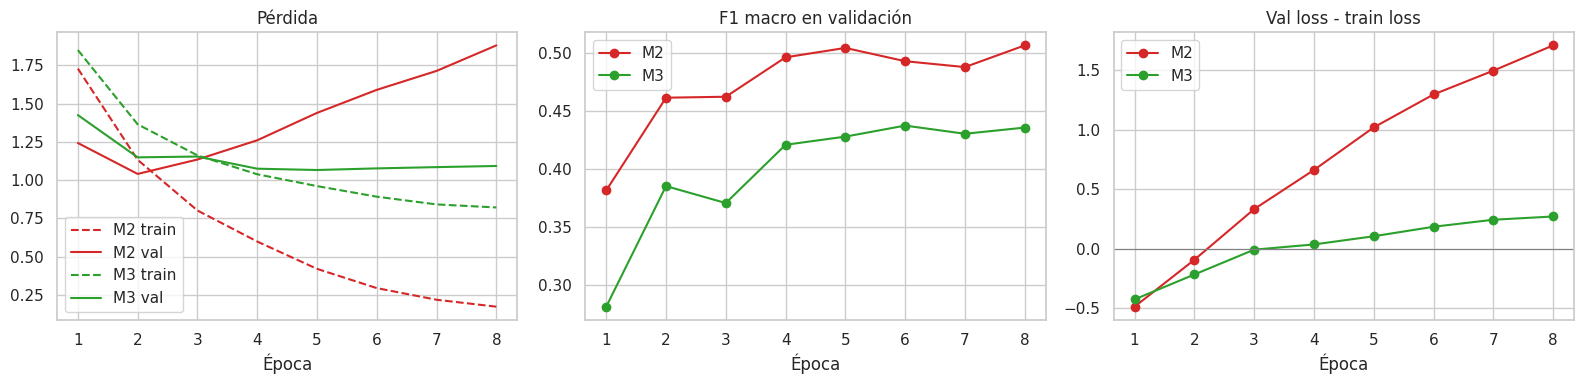

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for key, color in (("M2", "tab:red"), ("M3", "tab:green")):
    h = RESULTS[(key, SEEDS[0])]["history"]
    axes[0].plot(h["epoch"], h["train_loss"], ls="--", color=color, label=f"{key} train")
    axes[0].plot(h["epoch"], h["val_loss"], color=color, label=f"{key} val")
    axes[1].plot(h["epoch"], h["val_f1"], marker="o", color=color, label=key)
    axes[2].plot(h["epoch"], h["val_loss"] - h["train_loss"], marker="o", color=color, label=key)
axes[0].set_title("Pérdida")
axes[1].set_title("F1 macro en validación")
axes[2].set_title("Val loss - train loss")
axes[2].axhline(0, color="gray", lw=0.8)
for a in axes:
    a.set_xlabel("Época")
    a.legend()
plt.tight_layout()
plt.show()

### Lectura de resultados
Sobre el conjunto de prueba (media de tres semillas), el F1 macro fue de 0.349 para M0, 0.369 para M1, 0.489 para M2 y 0.435 para M3.

- **Congelado frente a descongelado.** Pasar de M0 a M2 sube el F1 en 0.14, un salto mucho mayor que la desviación entre semillas (≤ 0.008). La representación general de BERTweet no alcanza para separar emociones, y el ajuste de todas las capas es lo que más aporta.
- **M0 frente a M1.** La head más grande mejora apenas 0.02. Es un aumento pequeño pero mayor que la variación entre semillas; aun así, el cuello de botella está en el embedding y no en el clasificador (esto se refuerza en 7.1).
- **Sobreajuste.** M2 es el que más memoriza: F1 de 0.88 en train frente a 0.49 en prueba, una brecha de 0.39. La pérdida de validación de M2 toca fondo en la época 2 y después sube hasta cerca de 1.9, mientras que su F1 de validación sigue mejorando hasta las épocas 6 a 8. El modelo sigue acertando más, pero con probabilidades cada vez más extremas y peor calibradas.
- **M3.** La regularización reduce la brecha de 0.39 a 0.12 y la pérdida de validación queda estable, pero cuesta 0.054 de F1 frente a M2. Con un F1 de train de 0.55, M3 se ve más bien limitado por exceso de regularización que sobreajustado.

## 7. Experimentos adicionales

### 7.1 Sobre embeddings congelados: pooling y tamaño de la head
Como los embeddings ya están calculados, se pueden probar variantes de forma barata. Primero se compara usar el `[CLS]` con el promedio de todos los tokens. En BERT sin ajustar, el `[CLS]` no fue entrenado para resumir la oración de forma general, así que el promedio suele representar mejor el texto.

In [17]:
pool_results = [RESULTS[(k, s)] for k in ("M0", "M1") for s in SEEDS]
for key in ("M0", "M1"):
    cfg = replace(CFGS[key], name=f"{CFGS[key].name} (mean pooling)", pooling="mean")
    pool_results += [run_experiment(cfg, s) for s in SEEDS]

summary_table(pool_results)[["val F1", "test F1", "test acc", "brecha (train-test)"]]

,val F1,test F1,test acc,brecha (train-test)
modelo,,,,
M0 Baseline,0.352 ± 0.008,0.349 ± 0.006,0.421 ± 0.009,0.074 ± 0.006
M1 MLP,0.383 ± 0.002,0.369 ± 0.008,0.458 ± 0.015,0.124 ± 0.025
M0 Baseline (mean pooling),0.433 ± 0.004,0.396 ± 0.002,0.481 ± 0.006,0.093 ± 0.006
M1 MLP (mean pooling),0.458 ± 0.003,0.419 ± 0.009,0.521 ± 0.008,0.211 ± 0.048


Ahora una búsqueda sobre la MLP (M1): tamaño de la capa oculta y dropout. Se elige con el F1 de **validación**, y el de prueba se mira solo como comprobación.

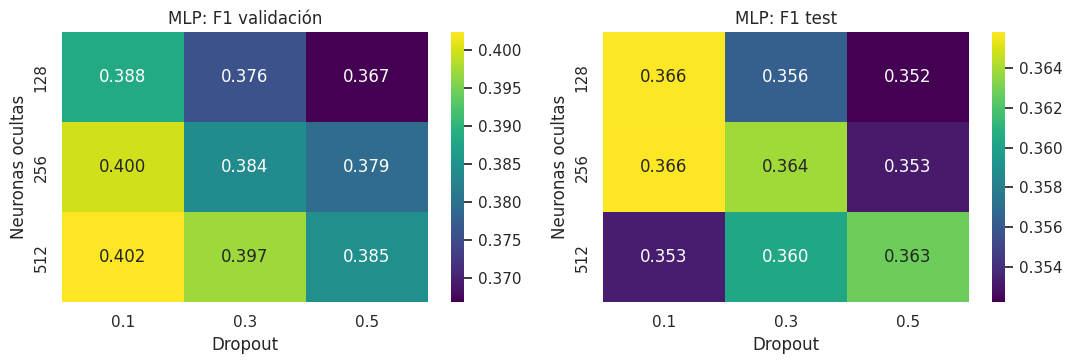

Mejor configuración según validación: 512 neuronas, dropout 0.1 -> test F1 = 0.353


In [18]:
hiddens, dropouts = [128, 256, 512], [0.1, 0.3, 0.5]
grid = pd.DataFrame(index=hiddens, columns=dropouts, dtype=float)
grid_test = grid.copy()
for h in hiddens:
    for d in dropouts:
        r = run_experiment(replace(CFGS["M1"], hidden=h, head_dropout=d), SEEDS[0])
        grid.loc[h, d], grid_test.loc[h, d] = r["val_f1"], r["test_f1"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, g, title in zip(axes, (grid, grid_test), ("F1 validación", "F1 test")):
    sns.heatmap(g, annot=True, fmt=".3f", cmap="viridis", ax=ax)
    ax.set_title(f"MLP: {title}")
    ax.set_xlabel("Dropout")
    ax.set_ylabel("Neuronas ocultas")
plt.tight_layout()
plt.show()

best_h, best_d = grid.stack().idxmax()
print(f"Mejor configuración según validación: {best_h} neuronas, dropout {best_d} "
      f"-> test F1 = {grid_test.loc[best_h, best_d]:.3f}")

### Lectura de 7.1
- **Pooling.** Promediar los tokens en vez de usar `[CLS]` sube el F1 de prueba de 0.349 a 0.396 en M0 y de 0.369 a 0.419 en M1. Son unos 0.05, más de lo que aporta la MLP sobre la capa lineal (0.02). Con el backbone congelado importa más cómo se resume el texto que el tamaño de la head.
- **Head MLP.** Las nueve combinaciones quedan entre 0.352 y 0.366 en prueba, un rango de 0.014 comparable al ruido entre semillas. La configuración que gana en validación (512 neuronas, dropout 0.1) ni siquiera es la mejor en prueba, así que en este problema el tamaño de la capa y el dropout de la MLP no cambian el resultado.
- El mejor modelo congelado (M1 con mean pooling, 0.419) sigue lejos de M2 (0.489).

### 7.2 Ablation de la regularización en fine-tuning
M3 junta cuatro mecanismos a la vez, y así no se sabe cuál hace el trabajo. Se parte de M2 y se agrega cada uno por separado (una semilla, por costo de cómputo). Como las diferencias pueden ser pequeñas, hay que leerlas con la desviación entre semillas de la tabla principal como referencia.

In [19]:
m2, m3 = CFGS["M2"], CFGS["M3"]
ablation = {
    "M2 (base)": RESULTS[("M2", SEEDS[0])],
    "+ weight decay 0.05": run_experiment(replace(m2, wd=m3.wd), SEEDS[0]),
    "+ label smoothing 0.1": run_experiment(replace(m2, smoothing=m3.smoothing), SEEDS[0]),
    "+ dropout (head 0.3, BERT 0.2)": run_experiment(replace(m2, head_dropout=m3.head_dropout, bert_dropout=m3.bert_dropout), SEEDS[0]),
    "+ LLRD 0.9": run_experiment(replace(m2, llrd=m3.llrd), SEEDS[0]),
    "M3 (los cuatro)": RESULTS[("M3", SEEDS[0])],
}
abl = pd.DataFrame({k: {"val F1": r["val_f1"], "test F1": r["test_f1"], "train F1": r["train_f1"],
                        "brecha": r["train_f1"] - r["test_f1"], "mejor época": r["best_epoch"]}
                    for k, r in ablation.items()}).T
abl.round(3)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
lm_head.decoder.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.decoder.bias        | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
lm_head.decoder.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.decoder.bias        | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
lm_head.decoder.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.decoder.bias        | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
lm_head.decoder.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.decoder.bias        | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,val F1,test F1,train F1,brecha,mejor época
M2 (base),0.506,0.481,0.920,0.438,8.0
+ weight decay 0.05,0.528,0.495,0.822,0.327,5.0
+ label smoothing 0.1,0.494,0.479,0.778,0.299,5.0
"+ dropout (head 0.3, BERT 0.2)",0.478,0.489,0.622,0.133,5.0
+ LLRD 0.9,0.504,0.483,0.718,0.236,5.0
M3 (los cuatro),0.437,0.435,0.547,0.113,6.0


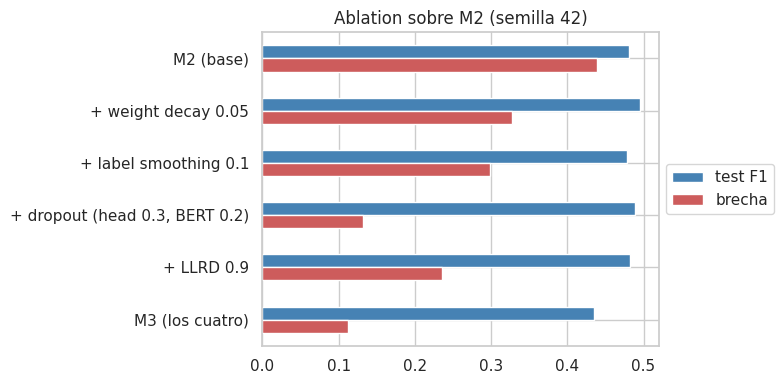

In [20]:
ax = abl[["test F1", "brecha"]].plot.barh(figsize=(8, 4), color=["steelblue", "indianred"])
ax.set_title(f"Ablation sobre M2 (semilla {SEEDS[0]})")
ax.invert_yaxis()
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

### Lectura de 7.2
Con una sola semilla y una desviación de M2 de unos 0.008, diferencias de 0.01 no se pueden interpretar. Lo que sí se ve con claridad:
- El **dropout** es el mecanismo más eficaz: baja la brecha de unos 0.44 a 0.13 sin perder F1 de prueba (queda cerca de 0.49).
- *Weight decay*, *label smoothing* y LLRD reducen la brecha de forma moderada (a 0.33, 0.30 y 0.24) y mantienen el F1 de M2.
- Al **combinar los cuatro** (M3) el F1 cae a 0.43 y la brecha a 0.11. Los mecanismos se acumulan y el modelo termina subajustado, así que M3 regulariza más de lo que este conjunto necesita.

## 8. Análisis de errores del mejor modelo
Como "mejor modelo" se elige el que tiene mayor F1 de validación promedio (no el de prueba, para no filtrar información del test en la decisión).

In [21]:
val_mean = {k: np.mean([RESULTS[(k, s)]["val_f1"] for s in SEEDS]) for k in CFGS}
BEST = max(val_mean, key=val_mean.get)
best = RESULTS[(BEST, SEEDS[0])]
base = RESULTS[("M0", SEEDS[0])]
print(f"Mejor modelo por validación: {CFGS[BEST].name}")
print(f"F1 macro en test (media de semillas): {np.mean([RESULTS[(BEST, s)]['test_f1'] for s in SEEDS]):.3f} "
      f"vs {np.mean([RESULTS[('M0', s)]['test_f1'] for s in SEEDS]):.3f} del baseline")

y_true = Y["test"].numpy()
print()
print(classification_report(y_true, best["test_pred"], target_names=LABELS, digits=3))

Mejor modelo por validación: M2 Fine-tuning
F1 macro en test (media de semillas): 0.489 vs 0.349 del baseline

              precision    recall  f1-score   support

       anger      0.377     0.295     0.331        78
     disgust      0.417     0.570     0.482       151
        fear      0.281     0.300     0.290        30
         joy      0.689     0.728     0.708       404
      others      0.680     0.608     0.642       651
     sadness      0.630     0.699     0.663        83
    surprise      0.262     0.244     0.253        45

    accuracy                          0.608      1442
   macro avg      0.477     0.492     0.481      1442
weighted avg      0.615     0.608     0.609      1442



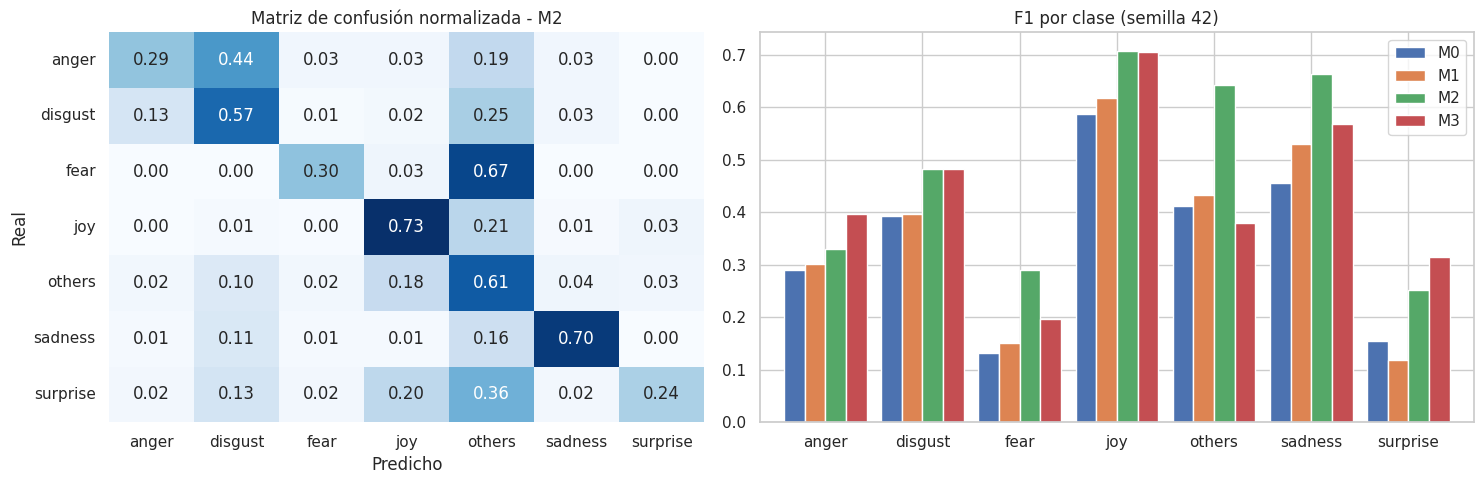

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 1.2]})

cm = confusion_matrix(y_true, best["test_pred"], normalize="true")
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, cbar=False, ax=axes[0])
axes[0].set_title(f"Matriz de confusión normalizada - {BEST}")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

f1_class = pd.DataFrame({k: f1_score(y_true, RESULTS[(k, SEEDS[0])]["test_pred"], average=None) for k in CFGS}, index=LABELS)
f1_class.plot.bar(ax=axes[1], width=0.85)
axes[1].set_title(f"F1 por clase (semilla {SEEDS[0]})")
axes[1].set_xlabel("")
plt.setp(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### Lectura por clase
- M2 acierta mejor las clases grandes: `joy` (F1 ≈ 0.71), `sadness` (0.66) y `others` (0.64), y `disgust` también rinde bien (0.48). Las más difíciles son `fear` (0.29, con solo 30 tuits en prueba), `surprise` (0.25, con 45) y `anger` (0.33). Con tan pocos ejemplos, estas cifras cambian bastante entre corridas.
- La confusión más llamativa es `anger` → `disgust`: el 44 % de los tuits de enojo se predicen como asco. Las dos emociones comparten tono ofensivo y vocabulario, y es una confusión que también se da entre anotadores. `fear` y `surprise` se van sobre todo a `others` (67 % y 36 %).
- M3 mejora `anger` (0.40) y `surprise` (0.31) pero baja `others` a 0.38. Al penalizar más los errores de las clases pequeñas y suavizar las etiquetas, predice más emociones minoritarias, y las paga en `others`. Depende de la aplicación cuál de los dos comportamientos conviene.

### Rendimiento por evento
Un modelo que solo reconoce el tema del evento y no la emoción se notaría aquí, con eventos donde le va muy bien y otros donde falla.

In [23]:
test_df = splits["test"].assign(pred=best["test_pred"], pred_base=base["test_pred"])
rows = []
for ev, d in test_df.groupby("event"):
    rows.append({"evento": ev, "tuits": len(d),
                 f"F1 macro {BEST}": f1_score(d["label"], d["pred"], average="macro"),
                 "F1 macro M0": f1_score(d["label"], d["pred_base"], average="macro"),
                 f"accuracy {BEST}": accuracy_score(d["label"], d["pred"])})
pd.DataFrame(rows).set_index("evento").sort_values("tuits", ascending=False).round(3)

,tuits,F1 macro M2,F1 macro M0,accuracy M2
evento,,,,
Venezuela,255,0.402,0.259,0.525
ChampionsLeague,252,0.403,0.226,0.579
NotreDame,233,0.462,0.217,0.584
GameOfThrones,227,0.479,0.262,0.643
WorldBookDay,224,0.216,0.224,0.647
GretaThunberg,147,0.310,0.210,0.626
LaLiga,68,0.286,0.188,0.735
SpainElection,36,0.619,0.545,0.778


### Lectura por evento
La mejora de M2 sobre M0 no es igual en todos los eventos. Es grande en Notre Dame (0.46 frente a 0.22), Venezuela y Champions League, pero en el Día del Libro M2 no supera al baseline (0.216 frente a 0.224), aunque su accuracy allí es alta porque casi todo es `joy` u `others`. Los eventos pequeños, como las elecciones (36 tuits), tienen métricas muy inestables. No hay señal de que el modelo solo esté reconociendo el tema, pero tampoco se puede descartar por completo en los eventos con pocas clases presentes.

### Errores concretos
Una muestra de tuits mal clasificados. Muchos suelen ser casos ambiguos incluso para una persona: ironía, mezcla de emociones o tuits informativos con una carga emocional leve.

In [24]:
wrong = test_df[test_df["label"] != test_df["pred"]].sample(12, random_state=0)
pd.set_option("display.max_colwidth", 140)
wrong.assign(real=wrong["emotion"], predicho=wrong["pred"].map(lambda i: LABELS[i]))[["clean", "real", "predicho"]] \
     .rename(columns={"clean": "tuit"}).reset_index(drop=True)

,tuit,real,predicho
0,Happy #WorldBookDay what are you reading ? Blood Oath by USER,others,joy
1,"Vidal you bastard , why did n't he shoot ? :enraged_face: :enraged_face: :enraged_face: #BARLIV #UCL #ChampionsLeague",others,anger
2,"A little late to post this , but it 's still just as true ... ! #IdiotInChief #MoronInChief #racist #racists #WhiteSupremacist #WhiteSup...",others,disgust
3,The world of books is the most remarkable creation of man . we wish you a very Happy World Book Day . . . Visit : HTTPURL Call : - 98266...,others,joy
4,USER_berlin USER This can't be true because #GretaThunberg can literally see the CO2 coming out of chimneys and warming the Earth ! :fac...,anger,others
5,"That time of year , when I remember the choir boy singing his heart out in a distant land and another century . This year Easter is more...",sadness,others
6,Sometimes you 've just got to admire the legend that is USER 600 club goals USER is another level ! :soccer_ball: :soccer_ball: #champio...,surprise,joy
7,USER USER There are TWO bad choices to decide between in #Venezuela for sure,anger,others
8,"pretty stunning how #Venezuela military is running over its own people , at Maduro 's Request . While we should pray for the citizens th...",others,disgust
9,""" #GlennBeck stating that the #NotreDameCathedralFire is France 's "" "" World Trade Center moment "" "" is a crazy statement due to the fac...",others,disgust


### Lectura de los errores
Varios errores son discutibles. "Happy World Book Day, what are you reading?" está etiquetado como `others` y el modelo dice `joy`, lo cual es razonable; "Vidal you bastard, why didn't he shoot" es `others` según el dataset y el modelo la lee como enojo. Es decir, parte del techo de desempeño viene de la frontera difusa de `others` y del ruido en las etiquetas, no solo del modelo. También se nota que la normalización convierte los emojis en texto (`:enraged_face:`), que el modelo aprovecha.

### Espacio de embeddings antes y después del ajuste
Se proyectan con PCA los embeddings `[CLS]` del conjunto de prueba en tres momentos: BERTweet congelado, M2 y M3. Si el fine-tuning funciona, las emociones deberían separarse más en el espacio de M2 y M3 que en el del backbone original. Para que se vea, se excluye `others`, que ocupa gran parte del espacio.

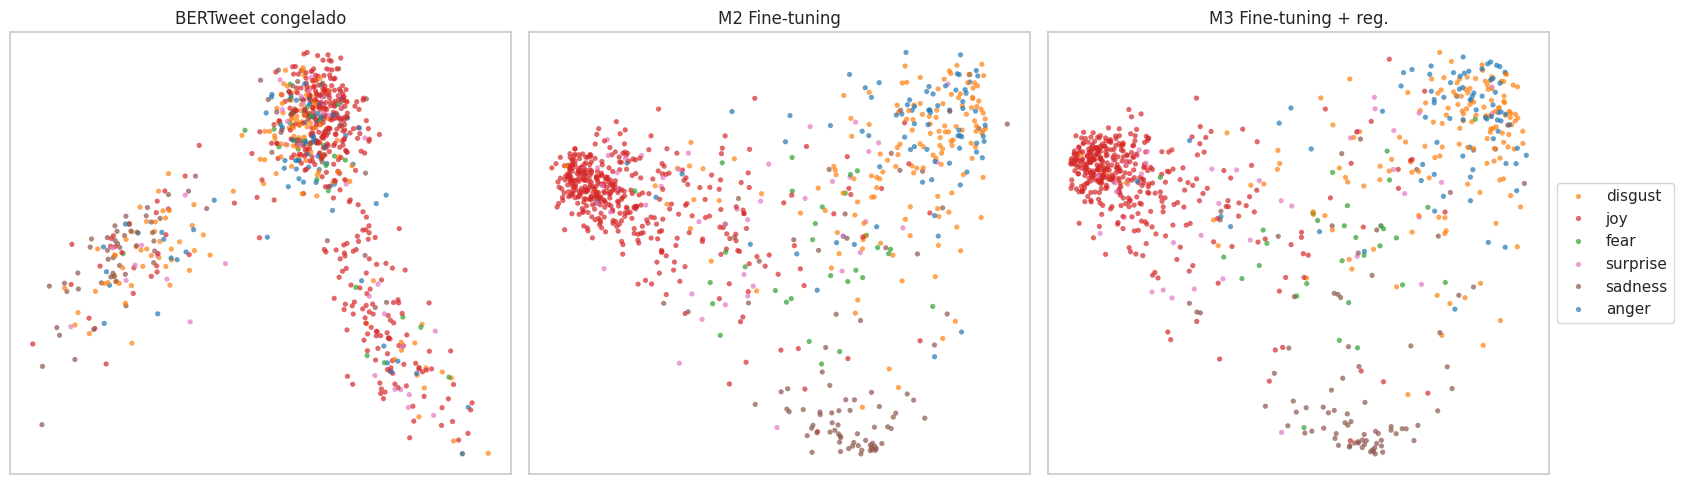

In [25]:
panels = {"BERTweet congelado": base["test_feats"],
          "M2 Fine-tuning": RESULTS[("M2", SEEDS[0])]["test_feats"],
          "M3 Fine-tuning + reg.": RESULTS[("M3", SEEDS[0])]["test_feats"]}
mask = y_true != LABEL2ID["others"]
palette = dict(zip(LABELS, sns.color_palette("tab10", N_CLASSES)))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (title, feats) in zip(axes, panels.items()):
    xy = PCA(n_components=2, random_state=0).fit_transform(feats[mask])
    sns.scatterplot(x=xy[:, 0], y=xy[:, 1], hue=np.array(LABELS)[y_true[mask]], palette=palette,
                    s=14, alpha=0.7, linewidth=0, ax=ax, legend=(ax is axes[-1]))
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
axes[-1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

### Lectura del PCA
Con el backbone congelado los tuits forman un continuo sin grupos claros, donde solo se intuye una separación entre alegría y emociones negativas. Tras el fine-tuning aparecen zonas definidas: `joy` a la izquierda, `sadness` abajo, y `disgust` y `anger` juntas arriba a la derecha, coherente con la confusión observada. `fear` y `surprise` quedan dispersas. M3 produce una nube un poco más compacta que M2, en línea con su menor sobreajuste.

## 9. Demo con frases nuevas
Se escribieron frases propias, que no vienen del dataset, para ver cómo se comporta el mejor modelo con fine-tuning. Se incluyen un caso neutro y uno irónico, que son los difíciles.

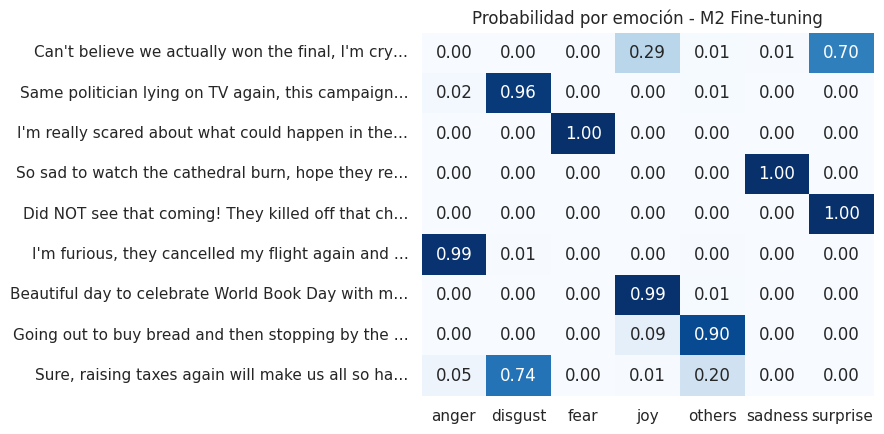

In [26]:
TUNED = max(("M2", "M3"), key=val_mean.get)
demo_model = RESULTS[(TUNED, SEEDS[0])]["model"].to(DEVICE).eval()


@torch.no_grad()
def predict_proba(texts):
    enc = tokenizer([clean_tweet(t) for t in texts], max_length=MAX_LEN, truncation=True, padding=True, return_tensors="pt")
    with torch.autocast(DEVICE, dtype=torch.float16, enabled=USE_AMP):
        logits = demo_model(enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE))
    return logits.float().softmax(-1).cpu().numpy()


frases = [
    "Can't believe we actually won the final, I'm crying happy tears 😭🏆",
    "Same politician lying on TV again, this campaign is disgusting",
    "I'm really scared about what could happen in the election on Sunday",
    "So sad to watch the cathedral burn, hope they rebuild it soon",
    "Did NOT see that coming! They killed off that character in the last episode 😱",
    "I'm furious, they cancelled my flight again and nobody explains anything 😡",
    "Beautiful day to celebrate World Book Day with my kids ❤️",
    "Going out to buy bread and then stopping by the library",
    "Sure, raising taxes again will make us all so happy 🙄",
]
probs = pd.DataFrame(predict_proba(frases), columns=LABELS, index=[f[:48] + ("…" if len(f) > 48 else "") for f in frases])
plt.figure(figsize=(9, 4.5))
sns.heatmap(probs, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False)
plt.title(f"Probabilidad por emoción - {CFGS[TUNED].name}")
plt.tight_layout()
plt.show()

### Lectura de la demo
El modelo acierta ocho de las nueve frases, la mayoría con probabilidad cercana a 1. Se equivoca en "Can't believe we actually won the final, I'm crying happy tears 😭🏆", que clasifica como `surprise` (0.70) y no como `joy` (0.29), probablemente por la mezcla de "can't believe" y el emoji de llanto. La frase irónica sobre los impuestos la lee como `disgust` (0.74), una lectura defendible, mientras que la frase neutra sale como `others` (0.90).

## 10. Resumen automático de resultados
Esta celda toma los números de la corrida para que las conclusiones se puedan contrastar con ellos.

In [27]:
mean_test = {k: np.mean([RESULTS[(k, s)]["test_f1"] for s in SEEDS]) for k in CFGS}
mean_gap = {k: np.mean([RESULTS[(k, s)]["train_f1"] - RESULTS[(k, s)]["test_f1"] for s in SEEDS]) for k in CFGS}
std_test = {k: np.std([RESULTS[(k, s)]["test_f1"] for s in SEEDS], ddof=1) for k in CFGS}
for k in CFGS:
    print(f"{CFGS[k].name:<24} test F1 {mean_test[k]:.3f} ± {std_test[k]:.3f} | brecha {mean_gap[k]:+.3f}")
print(f"\nM1 - M0 (head más compleja):      {mean_test['M1'] - mean_test['M0']:+.3f} F1")
print(f"M2 - M0 (fine-tuning completo):   {mean_test['M2'] - mean_test['M0']:+.3f} F1")
print(f"M3 - M2 (efecto regularización):  {mean_test['M3'] - mean_test['M2']:+.3f} F1 | brecha {mean_gap['M3'] - mean_gap['M2']:+.3f}")

M0 Baseline              test F1 0.349 ± 0.006 | brecha +0.074
M1 MLP                   test F1 0.369 ± 0.008 | brecha +0.124
M2 Fine-tuning           test F1 0.489 ± 0.008 | brecha +0.394
M3 Fine-tuning + reg.    test F1 0.435 ± 0.003 | brecha +0.115

M1 - M0 (head más compleja):      +0.021 F1
M2 - M0 (fine-tuning completo):   +0.140 F1
M3 - M2 (efecto regularización):  -0.054 F1 | brecha -0.279


## 11. Conclusiones

**Sobre la pregunta de investigación.** La decisión que más pesa es si se deja entrenar el backbone. Con BERTweet congelado, ni una head más grande (M1, 0.369) ni otro tipo de pooling (hasta 0.419) se acercan al fine-tuning completo (M2, 0.489). Las representaciones generales del modelo no están organizadas por emoción, y solo al ajustar todas las capas aparecen grupos claros por clase, como muestra el PCA. La hipótesis de que la head aportaría poco se cumple; la de que el fine-tuning mejoraría de forma clara, también.

**Sobre overfitting y generalización.** M2 sobreajusta con rapidez: su pérdida de validación empieza a subir en la segunda época y la brecha entre train y prueba llega a 0.39. La regularización controla eso (la brecha baja a 0.12 en M3), pero a costa de 0.054 de F1. El ablation explica por qué: el dropout solo ya reduce la brecha sin perder F1, y sumarle *weight decay*, *label smoothing* y LLRD produce un modelo subajustado. En este conjunto, una regularización más ligera sería mejor que la combinación de M3. Hay que recordar que el ablation se hizo con una sola semilla.

**Sobre el problema.** Las clases minoritarias (`fear`, `surprise`, `anger`) siguen siendo las más difíciles, con F1 entre 0.25 y 0.33, y se confunden con `others` o, en el caso de `anger`, con `disgust`. Parte de ese techo viene de la ambigüedad de las etiquetas más que del modelo. La mejora del fine-tuning tampoco es uniforme entre eventos: en el Día del Libro M2 apenas supera al baseline. La demo con frases nuevas funciona bien en los casos claros y falla cuando se mezclan señales contradictorias, como el llanto de alegría.

**Limitaciones y trabajo futuro.** Se usaron tres semillas y un solo split, lo que no equivale a una prueba estadística. Las clases pequeñas tienen muy pocos tuits en prueba (30 y 45), así que sus métricas son inestables. Como siguientes pasos se podría probar un M3 con solo dropout, comparar con un modelo no especializado en tuits como `bert-base-cased` para aislar el efecto del preentrenamiento en el dominio, aplicar un ajuste eficiente como LoRA y evaluar dejando un evento fuera del entrenamiento para medir la generalización a temas nuevos.